In [26]:
import networkx as nx
import matplotlib.pyplot as plt

In [27]:
"construct a graph example"
AG = nx.Graph()
Nodes = list(range(6))
print(Nodes)
AG.add_nodes_from(Nodes)
Edges = [(0,1),(0,2),(1,3),(2,3),(2,4),(3,5),(4,5)]
AG.add_edges_from(Edges)
print(AG)

[0, 1, 2, 3, 4, 5]
Graph with 6 nodes and 7 edges


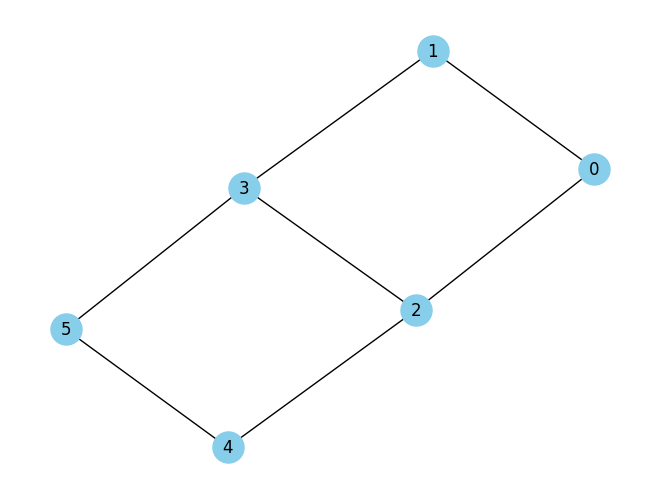

In [28]:
pos = nx.spring_layout(AG) #sl !!not sure if this is the correct layout for us!!
# Draw the nodes and edges
nx.draw(AG, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=12, font_color='black')
# Display the graph
plt.show()

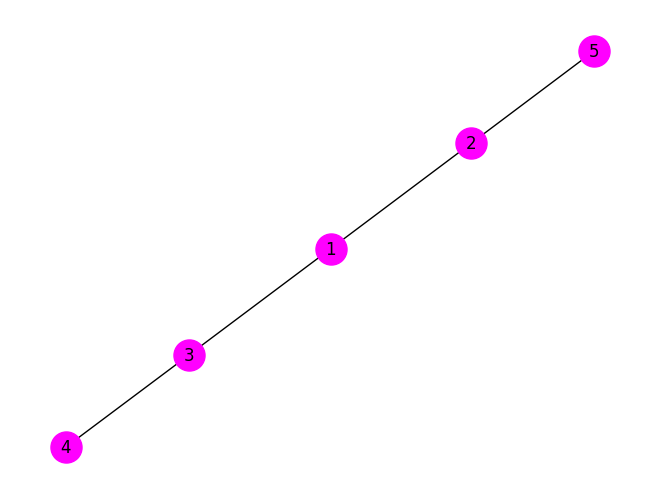

In [29]:
constraints = [[3,4],[2,5],[1,2],[1,3]]
g = nx.Graph()
g.add_edges_from(constraints)
pos = nx.spring_layout(g)
nx.draw(g, pos, with_labels=True, node_color='magenta', node_size=500, font_size=12, font_color='black')
plt.show()

The above 'constraint' graph g is embeddable into AG. We can transform a part of AG so that the constraints in g are all satisfied. That is, for each constraint, say [3,4], after token swapping, 3 and 4 are neighbors. The current constraint satisfaction degree is d(3,4)+d(2,5)+d(1,2)+d(1,3)=1+1+1+0=3, where d(p,q) is the minimum number of swaps required to bring p next to q. By performing the follow swaps, we can swap the tokens in a position which satisfy all constraints: 

1. swap 2,4
2. swap 0,1
3. swap 1,4
4. swap 4,0

Our task is to design an algorithm for finding the optimal solution. This algorithm could be based on depth-first search, A* search, or Z3 solver.

In [30]:
def print_graph(g):
    pos = nx.spring_layout(g)
    nx.draw(g, pos, with_labels=True, node_color='magenta', node_size=500, font_size=12, font_color='black')
    plt.show()    
    
def token_swap(g,swap):
    p,q = swap
    Edges = g.edges()
    modified_edges = []
    for edge in Edges:
        s, t = edge
        if p not in edge and q not in edge:
            modified_edges.append(edge)
        elif p in edge and q in edge:
            modified_edges.append(edge)
        elif p==s:
            modified_edges.append((q,t))
        elif q==s:
            modified_edges.append((p,t))
        elif p==t:
            modified_edges.append((q,s)) 
        else: #q==s
            modified_edges.append((p,s)) 
            
    modified_graph = nx.Graph()
    modified_graph.add_edges_from(modified_edges)
    return modified_graph    

swap [2, 4]


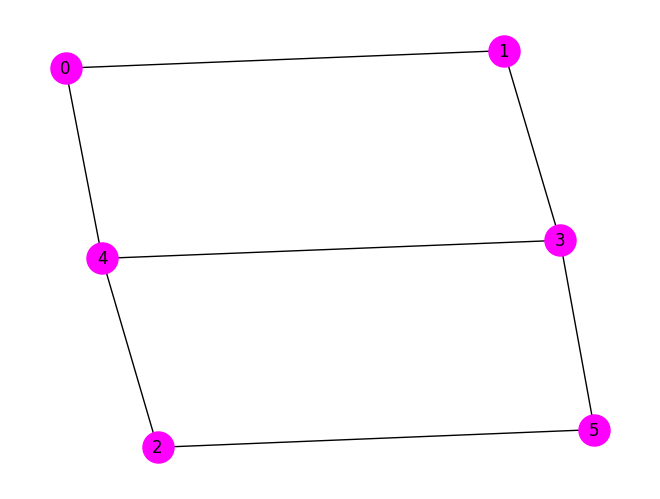

swap [0, 1]


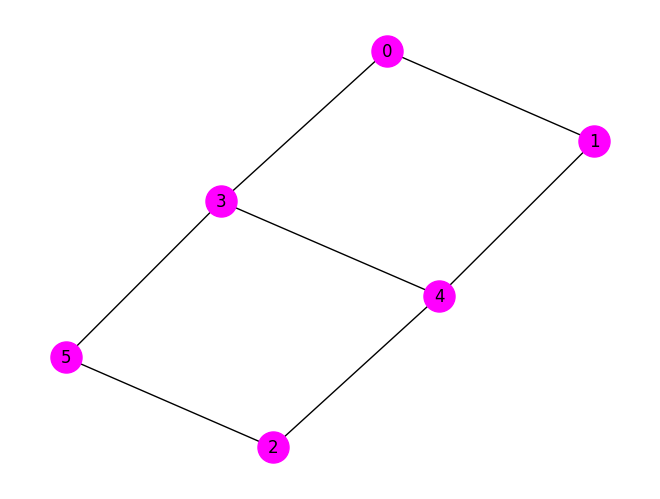

swap [1, 4]


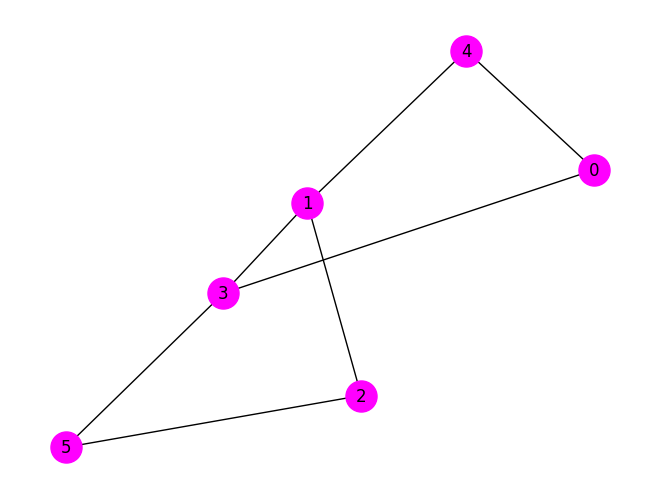

swap [4, 0]


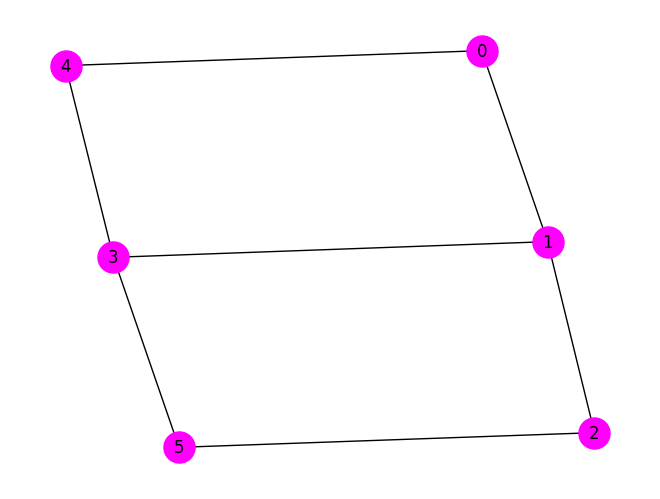

In [31]:
swap_list = [[2,4],[0,1],[1,4],[4,0]]
new_graph = AG.copy()
for swap in swap_list:
    new_graph = token_swap(new_graph, swap)
    print(f"swap {swap}")
    print_graph(new_graph)